In [2]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [43]:
df=pd.read_csv("onion.csv")

In [44]:
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller
adftest = adfuller(df['price'], autolag='AIC', regression='ct')
print("ADF-Statistic:", adftest[0])
print("P-Value:", adftest[1])
print("Number of lags:", adftest[2])
print("Number of observations:", adftest[3])
print("Critical Values:", adftest[4])
print("Note: If P-Value is smaller than 0.05, we reject the null hypothesis and the series is stationary")

ADF-Statistic: -4.977267455791521
P-Value: 0.00022628134574461707
Number of lags: 4
Number of observations: 283
Critical Values: {'1%': -3.9911206267519432, '5%': -3.4261186073262926, '10%': -3.1362363911557405}
Note: If P-Value is smaller than 0.05, we reject the null hypothesis and the series is stationary


In [32]:
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller
result = kpss(df['price'])
p_value = result[1]
print(p_value)


result1 = adfuller(df['price'])
p_value1 = result1[1]
print(p_value1)

0.04893328817827052
0.15192144439703048


In [45]:
from scipy import signal
import numpy as np
stationary_data = df['price'].diff().dropna()

detrended_data = signal.detrend(df['price'])

transformed_data = np.log(df['price'])


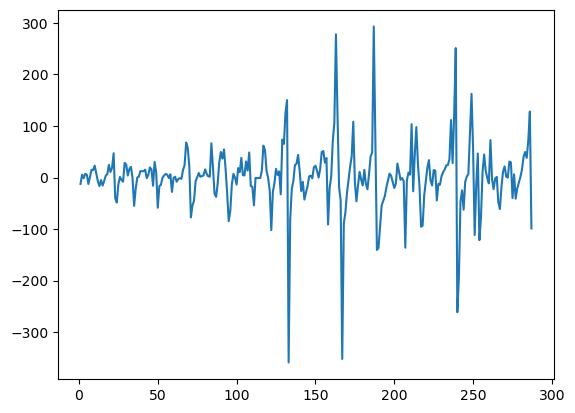

In [47]:
plt.plot(stationary_data)

Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    288.000000
mean     219.990278
std       96.572780
min      100.800000
25%      139.525000
50%      201.800000
75%      273.375000
max      445.300000
Name: price, dtype: float64


/Users/nithin/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


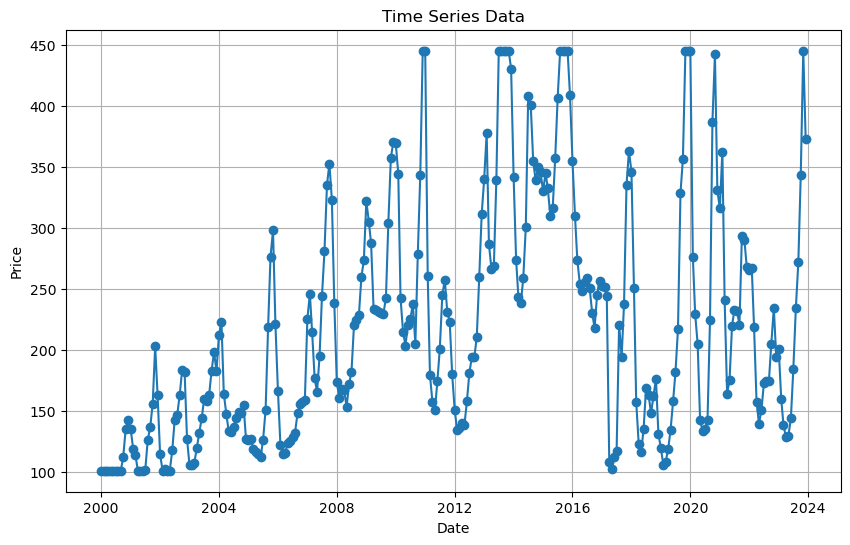

In [67]:
import pandas as pd


df['Date'] = pd.to_datetime(df['Date'])


print("Missing values:")
print(df.isnull().sum())


print("\nDuplicates:")
print(df.duplicated().sum())


print("\nBasic statistics of Price:")
print(df['price'].describe())


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


<Axes: >

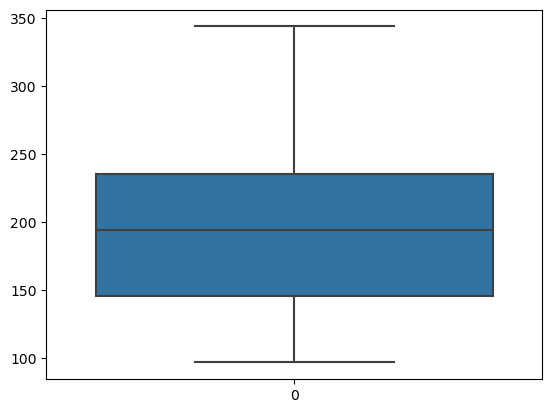

In [64]:
sn.boxplot(df['price'])

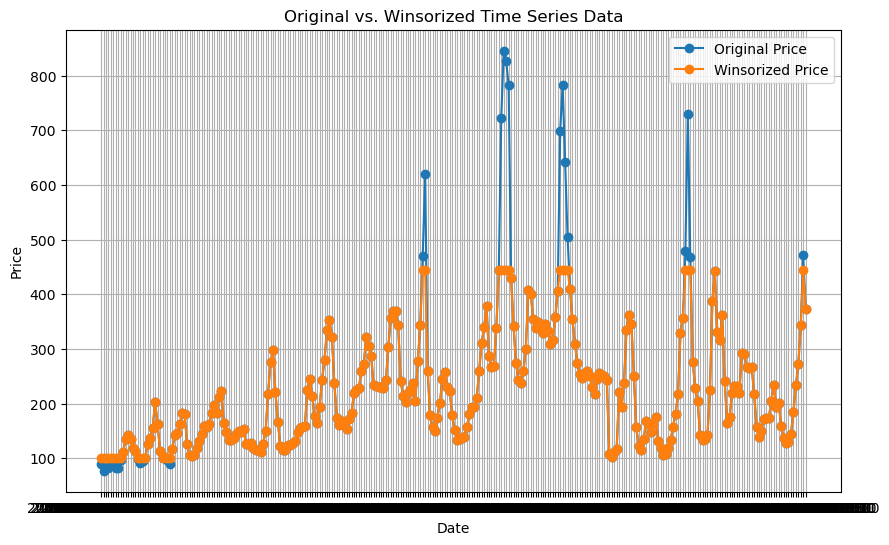

In [66]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values

df=pd.read_csv("onion.csv")
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)



import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
df.pop('price')
df['price']=df.pop('price1')

In [46]:
from scipy.stats import skew, kurtosis, shapiro

#df=pd.read_csv("DATA/Backup/onion.csv")

In [68]:
skewness = skew(df['price'])
kurt = kurtosis(df['price'])

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_p_value = shapiro(df['price'])

# Print the results
print("Skewness:", skewness)
print("Kurtosis:", kurt)
print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p_value)

Skewness: 0.7913230089770079
Kurtosis: -0.2771634273454948
Shapiro-Wilk Statistic: 0.9127762317657471
Shapiro-Wilk p-value: 6.837788581876003e-12


In [ ]:
rice:
mean     187.859722
std       32.163809
Skewness: 0.9157015411067952
Kurtosis: -0.6427567786532804
Shapiro-Wilk Statistic: 0.8303148746490479
Shapiro-Wilk p-value: 4.386655255398953e-17
    
wheat:
mean     192.399306
std       33.784052
Skewness: 0.6191595453778532
Kurtosis: -0.18814459707460562
Shapiro-Wilk Statistic: 0.9566423296928406
Shapiro-Wilk p-value: 1.4975772444358881e-07
    
maize:
mean     205.086111
std       47.012475
Skewness: 0.21081173276739495
Kurtosis: -0.7074047453650807
Shapiro-Wilk Statistic: 0.9750809073448181
Shapiro-Wilk p-value: 6.505934288725257e-05
    
potato:
mean     197.547917
std       66.286479
Skewness: 0.42931263053817065
Kurtosis: -0.4399531863305395
Shapiro-Wilk Statistic: 0.9613585472106934
Shapiro-Wilk p-value: 6.050657361811318e-07

onion:
mean     219.990278
std       96.572780
Skewness: 0.7913230089770079
Kurtosis: -0.2771634273454948
Shapiro-Wilk Statistic: 0.9127762317657471
Shapiro-Wilk p-value: 6.837788581876003e-12